# Experiment v3-a: Capital Feature Engineering

**목표**
- v3-a 전처리 (capital_gain/loss에 log1p + 존재 flag 추가) 적용
- v2 결과와 직접 비교 (ablation study)
- threshold tuning까지 동일하게 적용

**비교 기준점 (v2 + threshold 0.42)**
- F1: 0.7342
- AUC: 0.9297  
- (F1+AUC)/2: **0.8319**


## 1. 데이터 로드

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)


train shape: (39073, 15)
test shape: (9769, 14)


## 2. v3-a 전처리

v2 (Unknown category) + capital feature engineering.

In [3]:
# Step 1: Unknown category로 결측 채우기 (v2 동일)
cat_cols = [
    'workclass', 'education', 'marital_status', 'occupation',
    'relationship', 'race', 'sex', 'native_country'
]
for col in cat_cols:
    train_df[col] = train_df[col].fillna("Unknown")
    test_df[col] = test_df[col].fillna("Unknown")

# Step 2: v3-a 추가 - capital feature engineering
for df in [train_df, test_df]:
    # log1p transform: extreme value 완화 (99999 같은 값)
    df['capital_gain_log'] = np.log1p(df['capital_gain'])
    df['capital_loss_log'] = np.log1p(df['capital_loss'])

    # binary flag: gain/loss 존재 여부 자체를 feature로
    df['has_capital_gain'] = (df['capital_gain'] > 0).astype(int)
    df['has_capital_loss'] = (df['capital_loss'] > 0).astype(int)

# 확인
display(train_df[['capital_gain', 'capital_gain_log', 'has_capital_gain',
                  'capital_loss', 'capital_loss_log', 'has_capital_loss']].head())


,capital_gain,capital_gain_log,has_capital_gain,capital_loss,capital_loss_log,has_capital_loss
0,0,0.0,0,0,0.000000,0
1,0,0.0,0,0,0.000000,0
2,0,0.0,0,1902,7.551187,1
3,0,0.0,0,0,0.000000,0
4,0,0.0,0,0,0.000000,0


In [4]:
# Step 3: target 인코딩 + One-Hot Encoding
y_train = train_df["income"].map({"<=50K": 0, ">50K": 1})
test_id = test_df["id"]

train_features = train_df.drop(columns=["income", "id"])
test_features = test_df.drop(columns=["id"])

full_df = pd.concat([train_features, test_features], axis=0)
full_encoded = pd.get_dummies(full_df, columns=cat_cols)

X_train = full_encoded.iloc[:len(train_df)]
X_test = full_encoded.iloc[len(train_df):]

print("X_train shape:", X_train.shape, " (v2: 107 → v3-a: 111 예상)")
print("X_test shape:", X_test.shape)


X_train shape: (39073, 111)  (v2: 107 → v3-a: 111 예상)
X_test shape: (9769, 111)


## 3. Train/Validation Split + 평가 함수

In [5]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score

RANDOM_STATE = 42

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate(model, X_val, y_val, name="model"):
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)
    score = (f1 + auc) / 2
    print(f"[{name}]  F1 = {f1:.4f}  AUC = {auc:.4f}  (F1+AUC)/2 = {score:.4f}")
    return {"name": name, "f1": f1, "auc": auc, "score": score}

print("train:", X_tr.shape, "  val:", X_val.shape)


train: (31258, 111)   val: (7815, 111)


## 4. v3-a + XGBoost

In [6]:
from xgboost import XGBClassifier

xgb_v3a = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss'
)
xgb_v3a.fit(X_tr, y_tr)
xgb_v3a_result = evaluate(xgb_v3a, X_val, y_val, name="XGBoost v3-a")


[XGBoost v3-a]  F1 = 0.7199  AUC = 0.9297  (F1+AUC)/2 = 0.8248


In [7]:
# 5-fold CV
xgb_v3a_cv_f1 = cross_val_score(xgb_v3a, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
xgb_v3a_cv_auc = cross_val_score(xgb_v3a, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"XGBoost v3-a 5-fold CV F1 : {xgb_v3a_cv_f1.mean():.4f}  (±{xgb_v3a_cv_f1.std():.4f})")
print(f"XGBoost v3-a 5-fold CV AUC: {xgb_v3a_cv_auc.mean():.4f}  (±{xgb_v3a_cv_auc.std():.4f})")
print(f"XGBoost v3-a 5-fold CV (F1+AUC)/2: {(xgb_v3a_cv_f1.mean() + xgb_v3a_cv_auc.mean()) / 2:.4f}")


XGBoost v3-a 5-fold CV F1 : 0.7122  (±0.0033)
XGBoost v3-a 5-fold CV AUC: 0.9287  (±0.0037)
XGBoost v3-a 5-fold CV (F1+AUC)/2: 0.8204


## 5. v3-a + LightGBM

In [8]:
from lightgbm import LGBMClassifier

lgbm_v3a = LGBMClassifier(
    n_estimators=200, learning_rate=0.05,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgbm_v3a.fit(X_tr, y_tr)
lgbm_v3a_result = evaluate(lgbm_v3a, X_val, y_val, name="LightGBM v3-a")


[LightGBM v3-a]  F1 = 0.7179  AUC = 0.9291  (F1+AUC)/2 = 0.8235


In [9]:
# 5-fold CV
lgbm_v3a_cv_f1 = cross_val_score(lgbm_v3a, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
lgbm_v3a_cv_auc = cross_val_score(lgbm_v3a, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"LightGBM v3-a 5-fold CV F1 : {lgbm_v3a_cv_f1.mean():.4f}  (±{lgbm_v3a_cv_f1.std():.4f})")
print(f"LightGBM v3-a 5-fold CV AUC: {lgbm_v3a_cv_auc.mean():.4f}  (±{lgbm_v3a_cv_auc.std():.4f})")
print(f"LightGBM v3-a 5-fold CV (F1+AUC)/2: {(lgbm_v3a_cv_f1.mean() + lgbm_v3a_cv_auc.mean()) / 2:.4f}")


LightGBM v3-a 5-fold CV F1 : 0.7121  (±0.0033)
LightGBM v3-a 5-fold CV AUC: 0.9286  (±0.0038)
LightGBM v3-a 5-fold CV (F1+AUC)/2: 0.8204


## 6. Threshold Tuning

In [10]:
# 더 나은 모델 선택 (5-fold CV 기준)
xgb_v3a_cv_avg = (xgb_v3a_cv_f1.mean() + xgb_v3a_cv_auc.mean()) / 2
lgbm_v3a_cv_avg = (lgbm_v3a_cv_f1.mean() + lgbm_v3a_cv_auc.mean()) / 2

print(f"XGBoost v3-a CV 평균: {xgb_v3a_cv_avg:.4f}")
print(f"LightGBM v3-a CV 평균: {lgbm_v3a_cv_avg:.4f}")

if xgb_v3a_cv_avg >= lgbm_v3a_cv_avg:
    best_model = xgb_v3a
    best_model_name = "XGBoost v3-a"
else:
    best_model = lgbm_v3a
    best_model_name = "LightGBM v3-a"
print(f"\n→ Threshold tuning은 {best_model_name}로 진행")


XGBoost v3-a CV 평균: 0.8204
LightGBM v3-a CV 평균: 0.8204

→ Threshold tuning은 XGBoost v3-a로 진행


In [11]:
# Threshold scan
y_val_prob = best_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)
f1_scores = [f1_score(y_val, (y_val_prob >= t).astype(int)) for t in thresholds]

best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"기본 threshold (0.5) F1: {f1_score(y_val, (y_val_prob >= 0.5).astype(int)):.4f}")
print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1: {best_f1:.4f}")


기본 threshold (0.5) F1: 0.7199
Best threshold: 0.44
Best F1: 0.7350


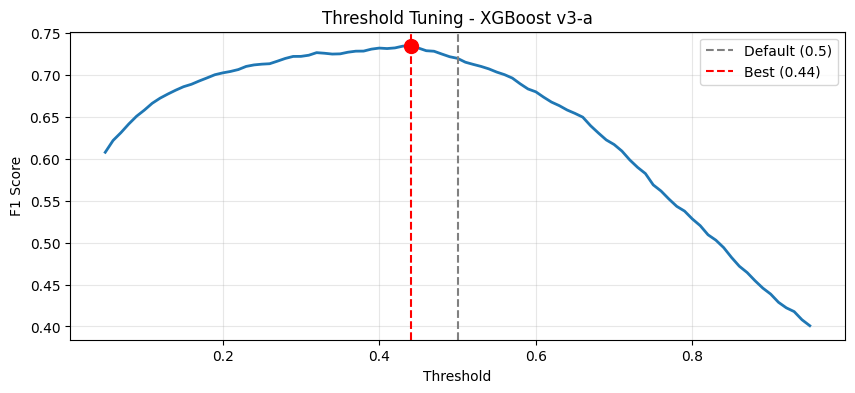

In [12]:
# 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores, linewidth=2)
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best ({best_threshold:.2f})')
plt.scatter([best_threshold], [best_f1], color='red', s=100, zorder=5)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title(f'Threshold Tuning - {best_model_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [13]:
# Best threshold 적용 후 최종 점수
y_val_pred_tuned = (y_val_prob >= best_threshold).astype(int)
f1_tuned = f1_score(y_val, y_val_pred_tuned)
auc_tuned = roc_auc_score(y_val, y_val_prob)
score_tuned = (f1_tuned + auc_tuned) / 2

print(f"[{best_model_name} + Threshold {best_threshold:.2f}]")
print(f"  F1 = {f1_tuned:.4f}")
print(f"  AUC = {auc_tuned:.4f}")
print(f"  (F1+AUC)/2 = {score_tuned:.4f}")


[XGBoost v3-a + Threshold 0.44]
  F1 = 0.7350
  AUC = 0.9297
  (F1+AUC)/2 = 0.8323


## 7. v2 vs v3-a 비교 (Ablation Study)

In [14]:
results_df = pd.DataFrame([
    # v2 결과 (이전 실험)
    {"Preprocessing": "v2",   "Model": "XGBoost",  "Threshold": 0.5,  "F1": 0.7204, "AUC": 0.9297, "Avg": 0.8250},
    {"Preprocessing": "v2",   "Model": "LightGBM", "Threshold": 0.5,  "F1": 0.7179, "AUC": 0.9291, "Avg": 0.8235},
    {"Preprocessing": "v2",   "Model": "XGBoost",  "Threshold": 0.42, "F1": 0.7342, "AUC": 0.9297, "Avg": 0.8319},
    # v3-a 결과 (이번 실험)
    {"Preprocessing": "v3-a", "Model": "XGBoost",  "Threshold": 0.5,  "F1": xgb_v3a_result['f1'],  "AUC": xgb_v3a_result['auc'],  "Avg": xgb_v3a_result['score']},
    {"Preprocessing": "v3-a", "Model": "LightGBM", "Threshold": 0.5,  "F1": lgbm_v3a_result['f1'], "AUC": lgbm_v3a_result['auc'], "Avg": lgbm_v3a_result['score']},
    {"Preprocessing": "v3-a", "Model": best_model_name.replace(" v3-a",""), "Threshold": round(best_threshold,2), "F1": f1_tuned, "AUC": auc_tuned, "Avg": score_tuned},
])

print(results_df.to_string(index=False))

# v3-a 효과 평가
v2_best = 0.8319
v3a_best = score_tuned
diff = v3a_best - v2_best
print(f"\nv2 best (0.8319) → v3-a best ({v3a_best:.4f}): {'+' if diff >= 0 else ''}{diff:.4f}")


Preprocessing    Model  Threshold       F1      AUC      Avg
           v2  XGBoost       0.50 0.720400 0.929700 0.825000
           v2 LightGBM       0.50 0.717900 0.929100 0.823500
           v2  XGBoost       0.42 0.734200 0.929700 0.831900
         v3-a  XGBoost       0.50 0.719909 0.929720 0.824814
         v3-a LightGBM       0.50 0.717919 0.929052 0.823485
         v3-a  XGBoost       0.44 0.734969 0.929720 0.832344

v2 best (0.8319) → v3-a best (0.8323): +0.0004


## 8. prediction.csv 생성 (조건부)

In [15]:
# v3-a가 v2보다 좋을 때만 prediction.csv 업데이트
if score_tuned > 0.8319:
    print(f"v3-a가 v2보다 좋음 ({score_tuned:.4f} > 0.8319) → prediction.csv 업데이트")

    if best_model_name == "XGBoost v3-a":
        final_model = XGBClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
            random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss'
        )
    else:
        final_model = LGBMClassifier(
            n_estimators=200, learning_rate=0.05,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        )

    final_model.fit(X_train, y_train)
    y_test_prob = final_model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_prob >= best_threshold).astype(int)

    prediction = pd.DataFrame({
        "id": test_id.values,
        "y_cls": y_test_pred,
        "y_prob": y_test_prob
    })
    prediction.to_csv("prediction.csv", index=False)
    print(f"prediction.csv saved, {len(prediction)} rows")
    print(f"y_cls 분포: {prediction['y_cls'].value_counts().to_dict()}")
else:
    print(f"v3-a가 v2보다 안 좋음 ({score_tuned:.4f} <= 0.8319) → prediction.csv 유지")
    print("팀에 결과 공유 후 v3-b, v3-c 시도 권장")


v3-a가 v2보다 좋음 (0.8323 > 0.8319) → prediction.csv 업데이트
prediction.csv saved, 9769 rows
y_cls 분포: {0: 7532, 1: 2237}
